## Introduction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./UPL25_matches2.csv')

In [2]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']

In [3]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled



In [4]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)
df['total_actions'] = df['total_accelerations'] + df['total_decelerations']

In [5]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')
volume_metrics.append('total_actions')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

In [6]:
uploaded_matches = {
    "Lugazi Fc": 30,
    "URA Fc": 30,
    "Vipers Sc": 30,
    "Mbarara City Fc": 30,
    "Soltilo Bright Stars Fc": 29,
    "Police Fc": 28,
    "Kitara Fc": 29,
    "Updf Fc": 29,
    "Kcca Fc": 29,
    "Nec Fc": 30,
    "Maroons Fc": 25,
    "Wakiso Giants Fc": 25,
    "Bul Fc": 30,
    "Sc Villa": 20,
    "Mbale Heroes Fc": 14,
    "Express Fc": 9
}

required_total_uploaded_matches = 30

In [7]:
matchday_order = [f'Md{i}' for i in range(1, 31)]


In [8]:
def plot_line_with_values(data, x_col, y_col, title=None, x_label=None, y_label=None, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)

    if x_col == 'Match Day':
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(md).replace('Md', 'MD ') for md in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=10)
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)

    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}',
            (x, y),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )

    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    plt.tight_layout()
    return ax


## Club Specifics


In [9]:
for i in uploaded_matches:
    print(i)

Lugazi Fc
URA Fc
Vipers Sc
Mbarara City Fc
Soltilo Bright Stars Fc
Police Fc
Kitara Fc
Updf Fc
Kcca Fc
Nec Fc
Maroons Fc
Wakiso Giants Fc
Bul Fc
Sc Villa
Mbale Heroes Fc
Express Fc


In [10]:
club = 'Kitara FC'
club = club.title()
club_df = df[df['club_for'] == club].copy()

In [11]:
def club_upload_stats(club, club_df, uploaded_matches, required_total_uploaded_matches):
    # Number of matches analysed
    number_of_analysed_matches = club_df['match_day'].nunique()

    # Number of matches uploaded
    number_of_uploaded_matches = uploaded_matches.get(club, 0)

    # Percentage upload
    percentage_upload = (number_of_uploaded_matches / required_total_uploaded_matches) * 100

    #number of players monitored
    number_of_unique_players = club_df['p_name'].nunique()

    return number_of_analysed_matches,number_of_uploaded_matches,percentage_upload,number_of_unique_players

In [12]:
def get_matchday_stats_styled(club_df, matchday_order, style_table_for_docs, club):
  # 1. Aggregate per match_day
  match_stats = (
    club_df
      .groupby('match_day', as_index=False)
      .agg({
        'club_against':'first',  # opponent club
        'p_name': 'nunique',     # unique players
        'duration': 'mean',       # average session duration
        'result':'first',
        'location': 'first',
      })
      .rename(columns={
        'club_against':'Opponent Club',
        'match_day': 'Match Day',
        'p_name': 'Number of Players Monitored',
        'duration': 'Average Session Duration (min)',
        'result': 'Match Result',
        'location': 'Match Location',
      })
  )

  # 2. Ensure all match days are present, fill missing with NaN/0
  full_md_df = pd.DataFrame({'Match Day': matchday_order})
  match_stats = full_md_df.merge(match_stats, on='Match Day', how='left')

  # Fill text columns with NaN and numeric columns with 0 for missing match days
  text_cols = ['Opponent Club', 'Match Result', 'Match Location']
  num_cols = ['Number of Players Monitored', 'Average Session Duration (min)']

  for col in text_cols:
    match_stats[col] = match_stats[col].where(match_stats[col].notna(), np.nan)
  for col in num_cols:
    match_stats[col] = match_stats[col].fillna(0)

  # 3. Optionally round the duration column
  match_stats['Average Session Duration (min)'] = match_stats['Average Session Duration (min)'].round(1)

  # 4. Style for docs
  styled = style_table_for_docs(match_stats)
  styled = styled.set_caption(f"Matches Monitored for {club}")
  return styled,match_stats


In [13]:
def plot_players_per_matchday(club_df, matchday_order, style_table_for_docs, club):
    match_stats = get_matchday_stats_styled(club_df, matchday_order, style_table_for_docs, club)[1]
    ax1 = plot_line_with_values(
        match_stats,
        'Match Day',
        'Number of Players Monitored',
        title='Player Number per Matchday',
        x_label='Match Day',
        y_label='Number of Players'
    )
    return ax1

In [14]:
def get_players_monitored_stats(club_df, style_table_for_docs, club):
    # 1. Aggregate to get position (first seen) and count of unique match days per player
    player_stats = (
        club_df
          .groupby('p_name', as_index=False)
          .agg({
              'general_position': 'first',
              'match_day': pd.Series.nunique
          })
          .rename(columns={'match_day': 'Match Days Analysed'})
    )

    # 2. Title‑case player names and sort
    player_stats['p_name'] = player_stats['p_name'].str.title()
    player_stats = player_stats.sort_values('p_name')

    # 3. Rename columns for display
    player_stats = player_stats.rename(columns={
        'p_name': 'Player Name',
        'general_position': 'Position'
    })

    # 4. Display with your styling function
    styled = style_table_for_docs(player_stats, hide_index=True)
    styled = styled.set_caption(f"Players Monitored for {club}")
    return styled, player_stats


In [15]:
def get_metric_summary_styled(club_df, volume_metrics, intensity_metrics, club, style_table_for_docs):
    x= club_df[volume_metrics + intensity_metrics].agg(['sum','max','min','mean','std'])
    x.rename(columns={
                                            'distance_km':'Distance',
                                            'sprint_distance_m':'Sprint Distance',
                                            'power_plays':'Power Plays',
                                            'energy_kcal':'Energy',
                                            'impacts':'Impacts',
                                            'total_accelerations':'Accelerations',
                                            'total_decelerations': 'Decelerations',
                                            'total_actions':'Total Actions',
                                            'player_load':'Player Load',
                                            'top_speed_kmh':'Top Speed',
                                            'distance_per_min_mmin':'Distance per Minute',
                                            'power_score_wkg':'Power Score',
                                            'work_ratio':'Work Ratio',
                                            'max_acceleration_mss':'Max Acceleration',
                                            'max_deceleration_mss':'Max Deceleration',
                                            'acc_counts_per_min':'Acceleration Counts per Min',
                                            'dec_counts_per_min':'Deceleration Counts per Min'},inplace=True)
    x = x.T.reset_index().rename(columns={'index': 'Metric','sum': 'Total', 'max': 'Max', 'min': 'Min', 'mean': 'Mean', 'std': 'Std Dev'})[['Metric', 'Total', 'Max', 'Min', 'Mean', 'Std Dev']]
    x['Range'] = x['Max'] - x['Min']
    
    return style_table_for_docs(x.round(2)).set_caption(f"Metric Summary for {club}"), x.round(2)

In [16]:
def get_top_players_by_metric(club_df, metrics, style_table_for_docs):
    top_players = []
    for metric in metrics:
        idx = club_df[metric].idxmax()
        row = club_df.loc[idx]
        top_players.append({
            'metric': metric,
            'player': row['p_name'],
            'value': row[metric],
            'match day': row['match_day']
        })
    top_players_df = pd.DataFrame(top_players)
    top_players_df['value'] = top_players_df['value'].round(2)
    top_players_df = pd.DataFrame(top_players).set_index('metric').T


    top_players_df.rename(columns={'distance_km':'Distance','sprint_distance_m':'Sprint Distance','power_plays':'Power Plays','energy_kcal':'Energy',
                                            'impacts':'Impacts','total_accelerations':'Accelerations',
                                            'total_decelerations': 'Decelerations','total_actions':'Total Actions',
                                            'player_load':'Player Load','top_speed_kmh':'Top Speed',
                                            'distance_per_min_mmin':'Distance per Minute','power_score_wkg':'Power Score','work_ratio':'Work Ratio',
                                            'max_acceleration_mss':'Max Acceleration','max_deceleration_mss':'Max Deceleration',
                                            'acc_counts_per_min':'Acceleration Counts per Min','dec_counts_per_min':'Deceleration Counts per Min'},inplace=True)
    top_players_df.drop(columns=['Max Acceleration','Max Deceleration'], inplace=True) 
    top_players_df = top_players_df.T
    top_players_df.reset_index(inplace=True)
    styled = style_table_for_docs(top_players_df.T)

    return styled, top_players_df

In [17]:
def get_avg_metrics_by_position(club_df, volume_metrics, intensity_metrics, style_table_for_docs):

    avg_metrics_by_position = club_df.groupby('general_position')[volume_metrics + intensity_metrics].mean().round(2).reset_index()

    avg_metrics_by_position.rename(columns={'general_position': 'Position',
                                            'distance_km':'Distance',
                                            'sprint_distance_m':'Sprint Distance',
                                            'power_plays':'Power Plays',
                                            'energy_kcal':'Energy',
                                            'impacts':'Impacts',
                                            'total_accelerations':'Accelerations',
                                            'total_decelerations': 'Decelerations',
                                            'total_actions':'Total Actions',
                                            'player_load':'Player Load',
                                            'top_speed_kmh':'Top Speed',
                                            'distance_per_min_mmin':'Distance per Minute',
                                            'power_score_wkg':'Power Score',
                                            'work_ratio':'Work Ratio',
                                            'max_acceleration_mss':'Max Acceleration',
                                            'max_deceleration_mss':'Max Deceleration',
                                            'acc_counts_per_min':'Acceleration Counts per Min',
                                            'dec_counts_per_min':'Deceleration Counts per Min'},inplace=True)
    
    avg_metrics_by_position.drop(columns=['Max Acceleration','Max Deceleration'], inplace=True) 
    styled = style_table_for_docs(avg_metrics_by_position)
    return styled, avg_metrics_by_position.T.reset_index()

In [18]:
def get_avg_metric_per_matchday(club_df, volume_metrics, intensity_metrics, matchday_order,style_table_for_docs):
    avg_metric_per_matchday = club_df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
    avg_metric_per_matchday['match_day'] = pd.Categorical(
        avg_metric_per_matchday['match_day'],
        categories=matchday_order,
        ordered=True
    )
    avg_metric_per_matchday = avg_metric_per_matchday.sort_values(by='match_day')
    avg_metric_per_matchday_plot = avg_metric_per_matchday.copy() 
    avg_metric_per_matchday.rename(columns={'match_day': 'Match Day',
                                            'distance_km':'Distance',
                                            'sprint_distance_m':'Sprint Distance',
                                            'power_plays':'Power Plays',
                                            'energy_kcal':'Energy',
                                            'impacts':'Impacts',
                                            'total_accelerations':'Accelerations',
                                            'total_decelerations': 'Decelerations',
                                            'total_actions':'Total Actions',
                                            'player_load':'Player Load',
                                            'top_speed_kmh':'Top Speed',
                                            'distance_per_min_mmin':'Distance per Minute',
                                            'power_score_wkg':'Power Score',
                                            'work_ratio':'Work Ratio',
                                            'max_acceleration_mss':'Max Acceleration',
                                            'max_deceleration_mss':'Max Deceleration',
                                            'acc_counts_per_min':'Acceleration Counts per Min',
                                            'dec_counts_per_min':'Deceleration Counts per Min'

                                            }, inplace=True)
    avg_metric_per_matchday.drop(columns=['Max Acceleration','Max Deceleration'], inplace=True) 
    styled = style_table_for_docs(avg_metric_per_matchday)
    return styled, avg_metric_per_matchday.round(1), avg_metric_per_matchday_plot.round(2)

In [19]:
def plot_club_metrics_across_matchdays(club_df, volume_metrics, intensity_metrics, matchday_order):
    avg_metric_per_matchday = get_avg_metric_per_matchday(club_df, volume_metrics, intensity_metrics, matchday_order, style_table_for_docs)[2]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    metrics = [
        ('distance_km', 'Distance (km)'),
        ('sprint_distance_m', 'Sprint Distance (m)'),
        ('player_load', 'Player Load'),
        ('top_speed_kmh', 'Top Speed (km/h)')
    ]
    md15_idx = matchday_order.index('Md15')
    for ax, (col, label) in zip(axes.flatten(), metrics):
        sns.lineplot(
            data=avg_metric_per_matchday,
            x='match_day',
            y=col,
            marker='o',
            ax=ax,
            label=f'Average {label}'
        )
        avg_value = avg_metric_per_matchday[col].mean()
        ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
        ax.axvline(md15_idx, color='black', linestyle=':', linewidth=1)
        ax.axvspan(-0.5, md15_idx - 0.5, color='skyblue', alpha=0.35)
        ax.axvspan(md15_idx - 0.5, md15_idx + 0.5, color='lightgreen', alpha=0.35)
        ax.axvspan(md15_idx + 0.5, len(matchday_order) - 0.5, color='lightgreen', alpha=0.35)
        xticklabels = [str(md).replace('Md', 'MD ') for md in avg_metric_per_matchday['match_day']]
        ax.set_xticks(range(len(avg_metric_per_matchday['match_day'])))
        ax.set_xticklabels(xticklabels, rotation=90)
        ax.set_title(f'{label} Across Match Days')
        ax.set_xlabel('Match Day')
        ax.set_ylabel(label)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False)
        ymin, ymax = ax.get_ylim()
        ax.text(md15_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
        ax.text(md15_idx + (len(matchday_order)-md15_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()
    return fig


In [20]:
def plot_speed_zone_pct_by_position(club_df, position_order=None, ax=None):
    speed_zone_cols = [
        'distance_in_speed_zone_1_km',
        'distance_in_speed_zone_2_km',
        'distance_in_speed_zone_3_km',
        'distance_in_speed_zone_4_km',
        'distance_in_speed_zone_5_km'
    ]
    # Group by position and sum distances (in km)
    zone_by_position = club_df.groupby('general_position')[speed_zone_cols].sum()
    # Reorder positions if desired
    if position_order is not None:
        zone_by_position = zone_by_position.reindex(position_order)
        zone_by_position.index = [f"{pos}s" for pos in position_order]
    else:
        zone_by_position.index = [f"{pos}s" for pos in zone_by_position.index]
    # Prepare labels
    zone_labels = [f"Zone {i+1}" for i in range(len(speed_zone_cols))]
    zone_by_position.columns = zone_labels
    # Convert to percentages row-wise
    zone_pct = zone_by_position.div(zone_by_position.sum(axis=1), axis=0) * 100
    # Plot
    if ax is None:
        ax = zone_pct.plot(
            kind='bar',
            stacked=True,
            figsize=(10, 6),
            color=sns.color_palette('viridis', n_colors=len(zone_labels))
        )
    else:
        zone_pct.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            color=sns.color_palette('viridis', n_colors=len(zone_labels))
        )
    # Annotate values inside each bar segment (as percentages, one decimal)
    for i, pos in enumerate(zone_pct.index):
        cumulative = 0
        for j, zone in enumerate(zone_labels):
            value = zone_pct.loc[pos, zone]
            height = value
            y = cumulative + height / 2
            if value > 0.05:
                ax.text(
                    i, y, f"{value:.1f}%",
                    ha='center', va='center', fontsize=9,
                    color='black' if j > 1 else 'white', fontweight='bold'
                )
            cumulative += height
    ax.set_xlabel('Position Group')
    ax.set_title('Percentage of Total Distance Covered by Position in Each Speed Zone', pad=30)
    ax.set_xticks(range(len(zone_pct.index)))
    ax.set_xticklabels(zone_pct.index, rotation=0)
    ax.legend(title='Speed Zone', frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#E0DCDD')
    ax.set_facecolor('#F5F5F5')
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_yticks(range(0, 101, 20))
    ax.set_ylim(0, 100)
    plt.tight_layout()
    return ax, zone_by_position, zone_pct


## Club Comparisons

In [21]:
def club_vs_season_metric_comparison(club_df, df, volume_metrics,intensity_metrics, club, style_table_for_docs):
  metrics = volume_metrics + intensity_metrics
  # 1. Calculate club average
  club_avg = club_df[metrics].mean().to_frame(name='Club Average')
  # 2. Calculate season average
  season_avg = df[metrics].mean().to_frame(name='Season Average')
  # 3. Combine them
  comparison_df = club_avg.join(season_avg)
  # 4. Rank all clubs for each metric and extract your club’s position
  club_ranks = (
    df.groupby('club_for', observed=False)[metrics]
      .mean()
      .rank(ascending=False)
      .loc[club]
      .to_frame(name='Position (out of 16)')
  )
  # 5. Final combined table
  comparison_df = comparison_df.join(club_ranks.astype(int))
  comparison_df = comparison_df.round(2).T
  comparison_df.rename(columns={'index': 'Metric',
                                'distance_km':'Distance',
                                            'sprint_distance_m':'Sprint Distance',
                                            'power_plays':'Power Plays',
                                            'energy_kcal':'Energy',
                                            'impacts':'Impacts',
                                            'total_accelerations':'Accelerations',
                                            'total_decelerations': 'Decelerations',
                                            'total_actions':'Total Actions',
                                            'player_load':'Player Load',
                                            'top_speed_kmh':'Top Speed',
                                            'distance_per_min_mmin':'Distance per Minute',
                                            'power_score_wkg':'Power Score',
                                            'work_ratio':'Work Ratio',
                                            'max_acceleration_mss':'Max Acceleration',
                                            'max_deceleration_mss':'Max Deceleration',
                                            'acc_counts_per_min':'Acceleration Counts per Min',
                                            'dec_counts_per_min':'Deceleration Counts per Min'}, inplace=True)
  comparison_df.drop(columns=['Max Acceleration','Max Deceleration'], inplace=True) 

  #6. calculate percentage
  comparison_df= comparison_df.T
  comparison_df['% Difference'] = ((comparison_df['Club Average'] - comparison_df['Season Average']) / comparison_df['Season Average']) * 100

  # 7. Reorder columns
  ordered_cols = ['Club Average', 'Season Average', '% Difference', 'Position (out of 16)']
  comparison_df = comparison_df[ordered_cols]

  #change position to integer
  comparison_df['Position (out of 16)'] = comparison_df['Position (out of 16)'].astype(int)

  comparison_df= comparison_df.T

  # 8. Display styled
  return style_table_for_docs(comparison_df), comparison_df.round(2)


In [22]:
def positional_metric_comparison(club_df, df, volume_metrics, intensity_metrics, style_table_for_docs, club):
    metrics = volume_metrics + intensity_metrics
    club_avg = club_df.groupby('general_position')[metrics].mean().add_prefix("Club_")
    season_avg = df.groupby('general_position')[metrics].mean().add_prefix("Season_")
    combined = club_avg.join(season_avg)
    for metric in metrics:
        club_col = f"Club_{metric}"
        season_col = f"Season_{metric}"
        combined[f"%Diff_{metric}"] = (
            (combined[club_col] - combined[season_col]) / combined[season_col]
        ) * 100
    ordered_cols = []
    for metric in metrics:
        ordered_cols.extend([
            f"Club_{metric}",
            f"Season_{metric}",
            f"%Diff_{metric}"
        ])
    comparison_by_position = combined[ordered_cols].round(2).T
    comparison_by_position.reset_index(inplace=True)
    comparison_by_position.rename(columns={'index': 'Metric'}, inplace=True)
    
    styled = style_table_for_docs(comparison_by_position).set_caption(f"{club} vs League Positional Metrics Comparison")
    return styled, comparison_by_position


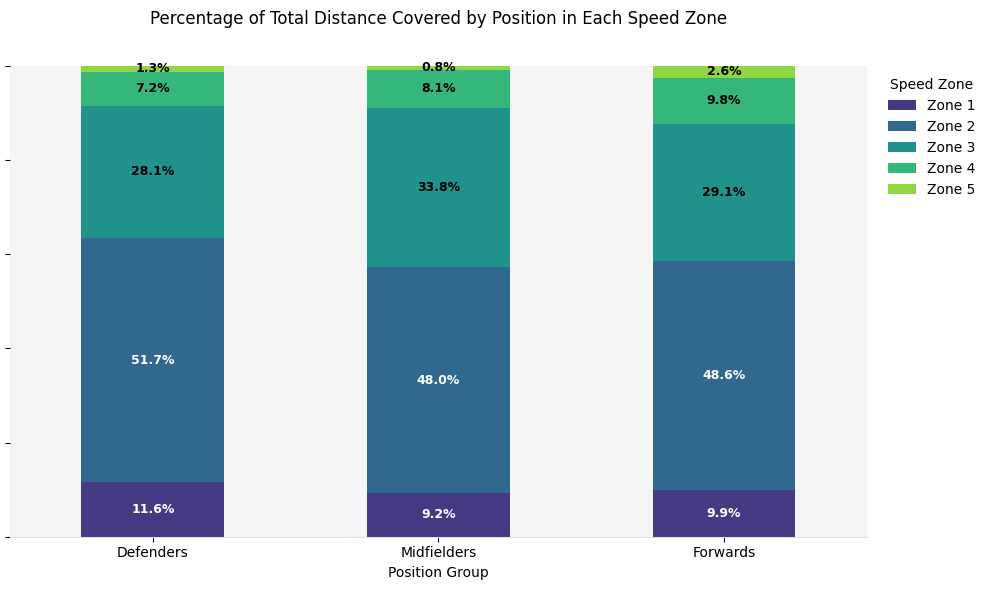

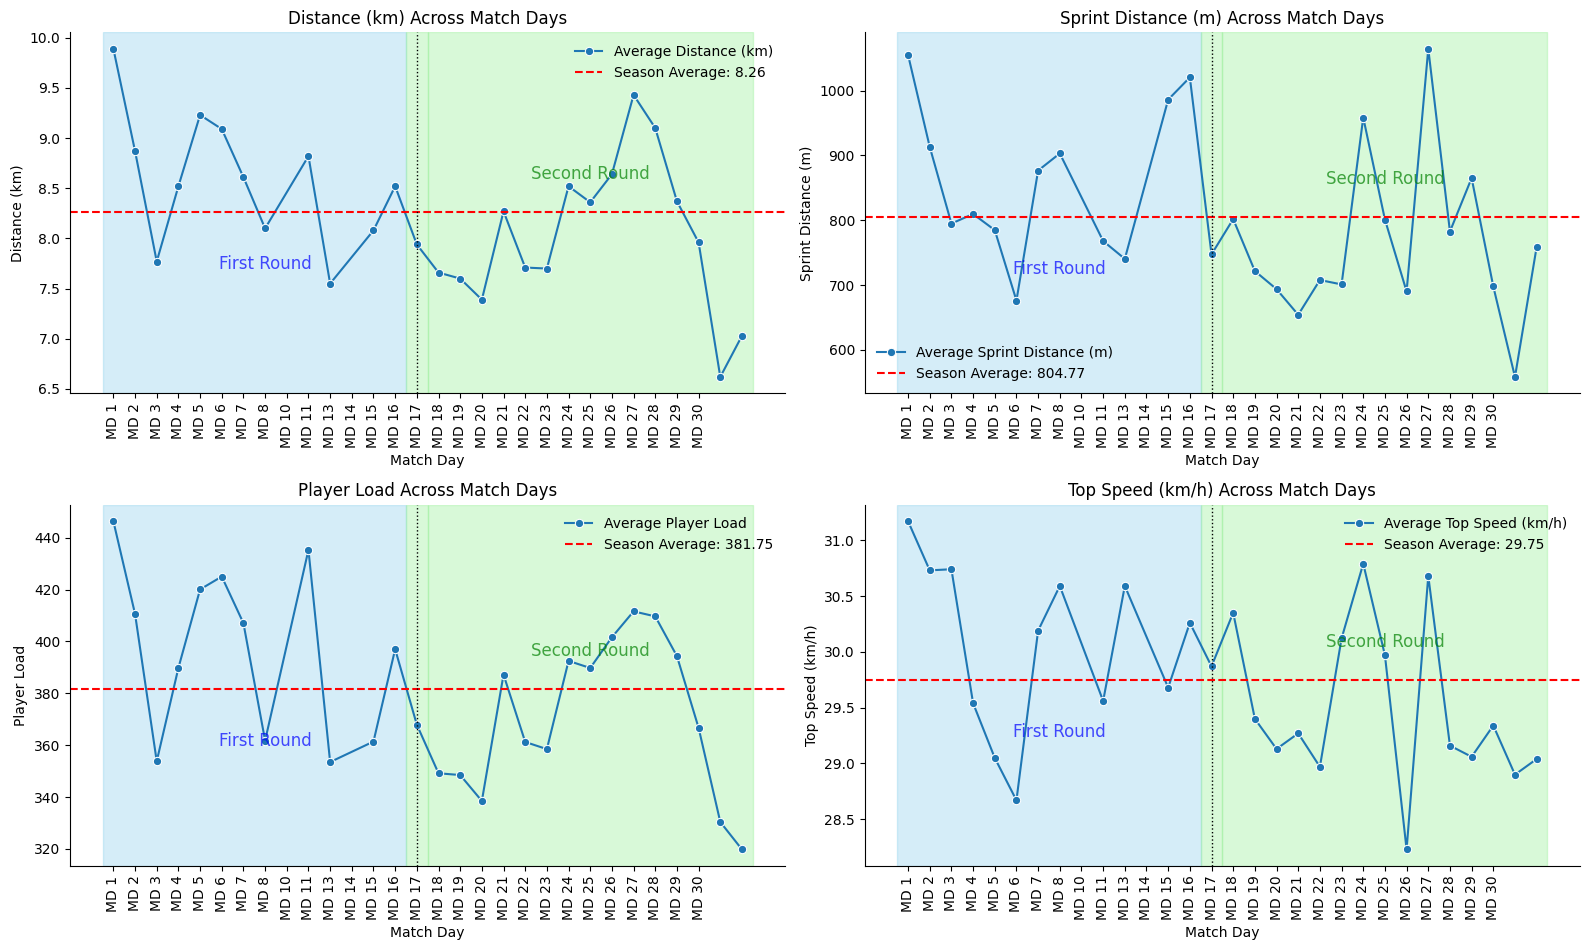

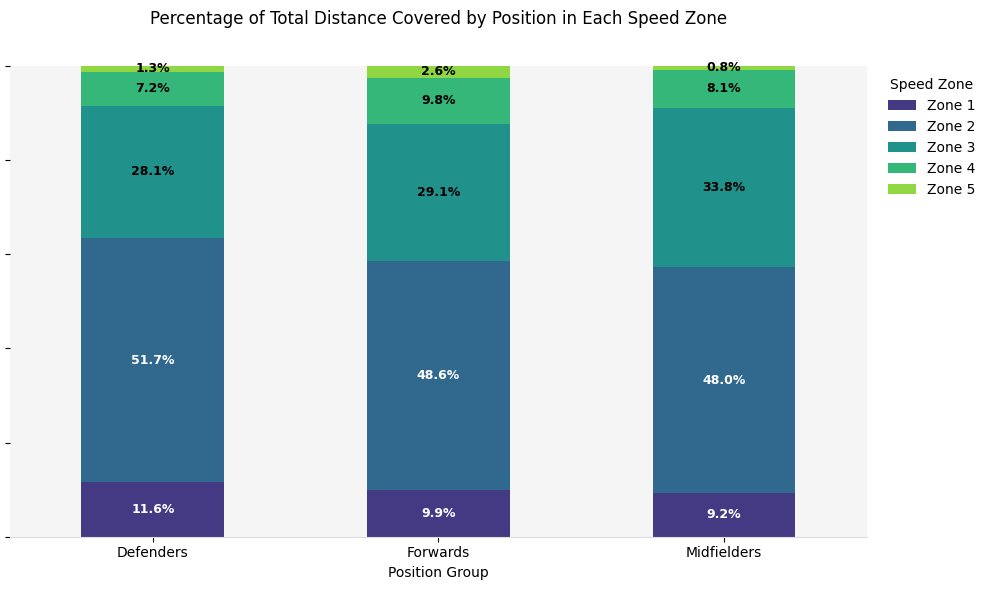

In [23]:
import os
import math
from docx import Document
from docx.shared import Inches

# Helper to format cell values safely
def fmt(val, float_fmt="{:.2f}"):
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return ""
    if isinstance(val, (int,)):
        return str(val)
    if isinstance(val, float):
        return float_fmt.format(val)
    return str(val)

def add_df_to_docx_table(doc, df):
    table = doc.add_table(rows=1, cols=len(df.columns))
    table.style = 'Table Grid'
    # Add header
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(df.columns):
        hdr_cells[i].text = str(col)
    # Add rows
    for idx, row in df.iterrows():
        row_cells = table.add_row().cells
        for i, val in enumerate(row):
            row_cells[i].text = str(val) if pd.notnull(val) else ""
    return table

out_dir = "reports"
os.makedirs(out_dir, exist_ok=True)

doc = Document()
doc.add_heading(f'{club} Catapult Report', 0)
doc.add_page_break()  # Add a page break for better organization


# Add introduction section
doc.add_heading('Introduction', level=1)
doc.add_paragraph(
    '''In a strategic move to enhance the performance and competitiveness, the Federation of Uganda Football Associations (FUFA) has made a significant investment in modern football technology. Substantial funds have been injected to purchase Catapult equipment, a state-of-the art performance monitoring system for clubs participating in the Uganda Premier League (UPL) and FUFA Women Super League (FWSL). This initiative underscores the Federation’s commitment to elevating the standards of football in Uganda through cutting-edge tools that support player development, match preparation,and overall team performance.''')

doc.add_paragraph(
    f'''This report summarizes the physical performance outputs of {club} using Catapult tracking data collected during the 2024/25 season. The aim is to provide a clear picture of player workloads, identify trends, and guide future performance strategies. This report presents an overview of player physical performance metrics for {club} captured using the Catapult GPS goal of using Catapult technology is to support evidence-based decision making in areas such as player monitoring, injury management, training load management, and overall performance benchmarking.'''
)

doc.add_paragraph(
    """By analysing the data collected across the season,this report aims to provide meaningful insights to the technical team and club management, enabling them to track player progress, adjust training programs, and make informed tactical or medical decisions."""
)

doc.add_paragraph("""It is important to note that the accuracy and completeness of the data depend on consistent device usage, correct session tagging and reliable synchronization procedures across all match days. Variations in data availability due to technical or logistical constraints have been highlighted where relevant.""")

doc.add_paragraph('''The report is structured into six key sections to provide a comprehensive overview of player physical performance across the 2024/25 season. The Methodology section explains how the data was collected, cleaned and analysed from all the clubs. The Season Results section presents individual and aggregated performance metrics derived from Catapult data,offering insights into physical output trends such as total distance covered, accelerations made etc. The Club Comparisons section benchmarks performance between clubs within the same league, highlighting variances in player volume and intensity, which may reflect differing technical or fitness strategies. The Challenges section outlines the recurring issues encountered during the season including inconsistent device usage and mislabelled sessions.Building on these insights, the Recommendations section proposes corrective actions such as Refresher training for Catapult operators and improved session standardisation. Finally, the FUFA Future Plans section outlines strategic steps the federation intends to take to enhance data usage, standardise reporting, and promote long term performance monitoring across all top-tier clubs. ''')

doc.add_page_break()  # Add a page break for better organization

doc.add_heading('Methodology', level=1)

doc.add_paragraph('''
This report is based on data collected using the Catapult GPS player tracking system during the 2024/25 football season. The data includes performancemetrics such as total distance covered, sprint distance, work ratio, player load, session availability, among others.

Data was collected and uploaded by trained club staff immediately after match sessions. The FUFA Research, Science & Technology (RST) unit oversaw the data collection process, ensuring sessions were split by halves, correctly labelled, and uploaded within 24 hours post-match. Where necessary, additional follow-up was done to correct mislabelled sessions or fill in missing data.

Data cleaning involved removing duplicates, resolving inconsistencies in player-pod assignments, and verifying that each match session met the minimum completeness threshold (e.g., full 90 minutes, minimum number of players tracked). Only match sessions with verified structure and consistent player tracking were included in the analysis.
                  
Performance indicators were aggregated by club and player, then analysed using descriptive statistics and visualized using Microsoft Excel, Power BI, R and Python. Comparisons between clubs were normalized to account for match frequency, number of players per squad, and available data. Clubs with fewer than 10 complete match sessions were excluded from comparative charts to preserve analytical accuracy.

All analyses were performed by the FUFA RST unit using internal data processing workflows. This methodology ensures the reliability and consistency of performance benchmarks used for technical review, club support, and long-term planning.
                  
''')
doc.add_page_break()  # Add a page break for better organization
doc.add_heading('Key Concepts and Definitions in Physical Performance Analysis', level=1)
doc.add_paragraph('''This section introduces the foundational concepts and key metrics commonly used in football physical performance analysis. It provides brief definitions of each term and examples of how these concepts are practically applied within the Ugandan football context. This section is essential for readers- especially club staff, coaches, analysts and administrators – who may be new to physical performance monitoring or are unfamiliar with the technical language used in such reports.''')
doc.add_heading('Physical Performance Analysis',level = 6)
doc.add_paragraph('''A method of collecting and interpreting data related to a player's physical output during training or matches. It helps coaches and performance staff understand workload, monitor fitness, manage fatigue, and prevent injury.''')
doc.add_heading('What is Catapult GPS Technology',level = 6)
doc.add_paragraph('''Catapult is a wearable athlete monitoring system that uses GPS and inertial sensors to capture real-time data on player movement, workload, and intensity. The system includes:''')

doc.add_page_break()  # Add a page break for better organization


# -------- 1. Summary of Player Metrics --------
doc.add_heading('Summary of Player Metrics', level=1)
doc.add_paragraph(f"Number of Matches Analysed: {fmt(club_upload_stats(club,club_df,uploaded_matches,required_total_uploaded_matches)[0], '{:.0f}')}")
# doc.add_paragraph(f"Number of Players Monitored: {fmt(club_upload_stats(club,club_df,uploaded_matches,required_total_uploaded_matches)[3], '{:.0f}')}")
doc.add_paragraph(f"Number of Matches Uploaded: {fmt(club_upload_stats(club,club_df,uploaded_matches,required_total_uploaded_matches)[1], '{:.0f}')}")
doc.add_paragraph(f"Percentage of Matches Uploaded: {fmt(club_upload_stats(club,club_df,uploaded_matches,required_total_uploaded_matches)[2], '{:.2f}')}%")

# Insert styled metric summary table
doc.add_heading('Player Metric Summary Table', level=2)
styled_metric_summary, _ = get_metric_summary_styled(club_df, volume_metrics, intensity_metrics, club, style_table_for_docs)
metric_summary_html = styled_metric_summary.to_html()
add_df_to_docx_table(doc, styled_metric_summary.data)

doc.add_paragraph()  # spacing

# -------- 2. Top Players by Metric --------
doc.add_heading('Top Players by Metric', level=1)
_,styled_top_players = get_top_players_by_metric(club_df, volume_metrics + intensity_metrics, style_table_for_docs)
add_df_to_docx_table(doc, styled_top_players)

doc.add_paragraph()

# -------- 3. Players Monitored --------
doc.add_heading('Players Monitored', level=1)
styled_players, _ = get_players_monitored_stats(club_df, style_table_for_docs, club)
add_df_to_docx_table(doc, styled_players.data)

doc.add_paragraph()

# -------- 4. Match Stats --------
doc.add_heading('Match Stats', level=1)
styled_match_stats, _ = get_matchday_stats_styled(club_df, matchday_order, style_table_for_docs, club)
add_df_to_docx_table(doc, styled_match_stats.data)

doc.add_paragraph()

# -------- 5. Metrics Per Position  --------
doc.add_heading('Average Metrics Per Position', level=1)
_,styled_avg_metrics_by_position = get_avg_metrics_by_position(club_df, volume_metrics, intensity_metrics, style_table_for_docs)
add_df_to_docx_table(doc, styled_avg_metrics_by_position)

doc.add_paragraph()

# -------- 6. Metric Per Matchday --------
doc.add_heading('Average Metrics Per Matchday', level=1)
styled_avg_metrics_per_match = get_avg_metric_per_matchday(club_df, volume_metrics, intensity_metrics, matchday_order,style_table_for_docs)
add_df_to_docx_table(doc, styled_avg_metrics_per_match[1])

doc.add_paragraph()

# -------- 8. Comparison  --------
doc.add_heading('Comparison Against Season Averages', level=1)
_,styled_comparison= club_vs_season_metric_comparison(club_df, df,volume_metrics,intensity_metrics,club, style_table_for_docs)
add_df_to_docx_table(doc, styled_comparison.T.reset_index())

doc.add_paragraph()

# -------- 9. Comparison by Position --------
doc.add_heading('Comparison by Position', level=1)
styled_position_comparison, _ = positional_metric_comparison(club_df, df,volume_metrics,intensity_metrics, style_table_for_docs, club)
add_df_to_docx_table(doc, styled_position_comparison.data)

doc.add_paragraph()

# -------- 9. Percentage of Distance in Speed Zone --------
doc.add_heading('Percentage of Distance in Speed Zone', level=1)
speed_zone_by_position= plot_speed_zone_pct_by_position(club_df,position_order=['Defender','Midfielder','Forward'])[2].round(2)
add_df_to_docx_table(doc,speed_zone_by_position.reset_index())

# -------- 6. Export plot figure and add to document --------
doc.add_heading('Club Metrics Plots', level=1)
from io import BytesIO

img_stream = BytesIO()
fig = plot_club_metrics_across_matchdays(club_df, volume_metrics, intensity_metrics, matchday_order)
fig.savefig(img_stream, format='png', bbox_inches='tight')
img_stream.seek(0)
doc.add_picture(img_stream, width=Inches(6))

doc.add_heading('Speed Zone Percentage by Position Plot', level=1)
img_zone_stream = BytesIO()
ax, zone_by_position, zone_pct= plot_speed_zone_pct_by_position(club_df, position_order=None)
ax.figure.savefig(img_zone_stream, format='png', bbox_inches='tight')
img_zone_stream.seek(0)
doc.add_picture(img_zone_stream, width=Inches(6))

doc.add_paragraph()

# # -------- Save the document --------
# out_file = os.path.join(out_dir, f"{club}_analysis_report.docx")
# doc.save(out_file)
# print(f"Saved report to: {out_file}")
